# Visualisation des resultats SRC V1

Ce notebook reprend le calcul de `main.py` et ajoute des graphes utiles pour la soutenance.
L'objectif est de montrer quelles vulnerabilites et quels hotes doivent etre traites en priorite, et pourquoi le SRC est plus pertinent que le CVSS seul.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

In [3]:
# === 1. POIDS DE PONDERATION ET CHARGEMENT DES DONNEES ===
W_EXPOSITION = {"Internet": 2.0, "DMZ": 1.5, "Interne": 1.0}
W_CRITICITE = {"Critique": 2.0, "Élevée": 1.5, "Moyenne": 1.0, "Faible": 0.5}
W_DONNEES = {"Sensible": 1.5, "Interne": 1.0, "Public": 0.5}

SRC_MAX_THEORIQUE = 10.0 * 2.0 * 2.0 * 1.5  # 60.0

vulns = pd.read_csv("data/payshield_vulns.csv")
infra = pd.read_csv("data/payshield_infrastructure.csv")

display(vulns.head())
print(f"Dataset vulnerabilites : {vulns.shape[0]} lignes x {vulns.shape[1]} colonnes")
print(f"Dataset infrastructure : {infra.shape[0]} lignes x {infra.shape[1]} colonnes")

,id,ip,port,service,version,cvss,cve,epss,exposition,criticite,donnees,description,kev
0,V01,10.0.0.10,443,OpenSSL,1.0.1,10.0,CVE-2014-0160,0.97,Internet,Critique,Sensible,Heartbleed — fuite mémoire SSL pouvant exposer...,1
1,V02,10.0.0.10,80,Apache,2.4.49,9.8,CVE-2021-41773,0.96,Internet,Critique,Sensible,Path traversal et RCE sans authentification su...,1
2,V03,10.0.0.10,22,OpenSSH,7.4,7.8,CVE-2018-15473,0.12,Internet,Critique,Sensible,Enumération des noms d'utilisateurs valides vi...,0
3,V04,10.0.0.10,8443,Node.js,14.0,8.1,CVE-2021-22931,0.08,Internet,Critique,Sensible,Corruption mémoire dans le runtime Node.js — p...,0
4,V05,10.0.0.15,5432,PostgreSQL,12.3,10.0,-,0.45,Interne,Critique,Sensible,Compte postgres sans mot de passe — accès root...,0


Dataset vulnerabilites : 35 lignes x 13 colonnes
Dataset infrastructure : 10 lignes x 12 colonnes


In [5]:
# === 2. CALCUL DU SRC V1 ===
vulns = vulns.copy()

vulns["w_exposition"] = vulns["exposition"].map(W_EXPOSITION)
vulns["w_criticite"] = vulns["criticite"].map(W_CRITICITE)
vulns["w_donnees"] = vulns["donnees"].map(W_DONNEES)

vulns["src"] = (
    vulns["cvss"]
    * vulns["w_exposition"]
    * vulns["w_criticite"]
    * vulns["w_donnees"]
)
vulns["src_norm"] = (vulns["src"] / SRC_MAX_THEORIQUE * 10).round(2)
vulns["ecart_src_cvss"] = (vulns["src_norm"] - vulns["cvss"]).round(2)

top10 = (
    vulns[["id", "ip", "service", "cve", "cvss", "exposition", "criticite", "donnees", "src_norm", "description"]]
    .sort_values("src_norm", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index += 1

resume = (
    vulns.groupby("ip")
    .agg(src_max=("src_norm", "max"), nb_vulns=("id", "count"))
    .reset_index()
    .merge(infra[["ip", "nom", "role"]], on="ip", how="left")
    .sort_values("src_max", ascending=False)
    .reset_index(drop=True)
)
resume.index += 1

comparaison = vulns[["id", "ip", "service", "cvss", "src_norm", "ecart_src_cvss", "exposition", "criticite", "donnees"]].copy()

## Graphe 1 - Top 10 des vulnerabilites selon le SRC V1

Ce graphe sert a montrer l'ordre de priorite de remediation. On ne regarde plus seulement la gravite technique, mais la gravite contextualisee pour PayShield.

,id,ip,service,cve,cvss,src_norm,description
1,V01,10.0.0.10,OpenSSL,CVE-2014-0160,10.0,10.00,Heartbleed — fuite mémoire SSL pouvant exposer...
2,V02,10.0.0.10,Apache,CVE-2021-41773,9.8,9.80,Path traversal et RCE sans authentification su...
3,V34,10.0.0.10,Kubernetes API,CVE-2020-8554,9.8,9.80,Man-in-the-middle via ExternalIP services — in...
4,V04,10.0.0.10,Node.js,CVE-2021-22931,8.1,8.10,Corruption mémoire dans le runtime Node.js — p...
5,V03,10.0.0.10,OpenSSH,CVE-2018-15473,7.8,7.80,Enumération des noms d'utilisateurs valides vi...
6,V11,10.0.0.25,Keycloak,CVE-2021-3461,9.8,7.35,Contournement d'authentification SSO via token...
7,V21,10.0.0.40,pfSense,CVE-2021-41282,9.8,6.53,Injection de commandes shell dans l'interface ...
8,V12,10.0.0.25,Keycloak,CVE-2020-1714,8.1,6.07,Injection de code côté serveur via template Fr...
9,V22,10.0.0.40,pfSense,CVE-2022-31814,8.8,5.87,CSRF permettant la modification de règles fire...
10,V23,10.0.0.40,OpenSSH,CVE-2023-38408,7.8,5.20,RCE via agent SSH forwarding dans OpenSSH < 9.3


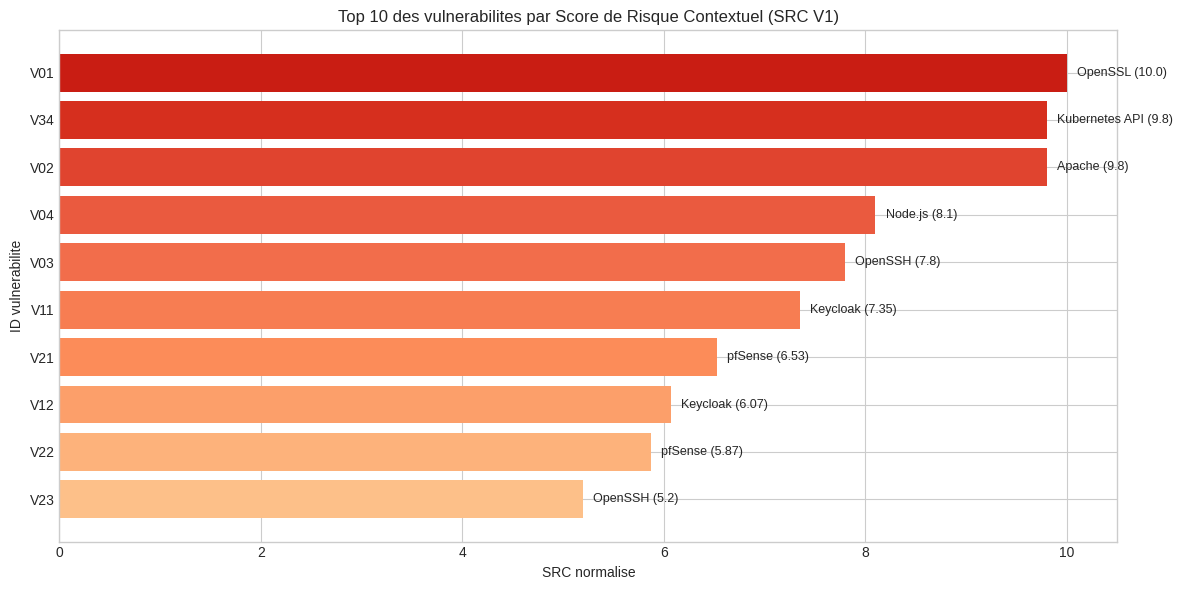

In [6]:
display(top10[["id", "ip", "service", "cve", "cvss", "src_norm", "description"]])

plot_top10 = top10.sort_values("src_norm")
colors = [plt.cm.OrRd(0.35 + 0.05 * i) for i in range(len(plot_top10))]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(plot_top10["id"], plot_top10["src_norm"], color=colors)

ax.set_title("Top 10 des vulnerabilites par Score de Risque Contextuel (SRC V1)")
ax.set_xlabel("SRC normalise")
ax.set_ylabel("ID vulnerabilite")
ax.set_xlim(0, 10.5)

for bar, service, score in zip(bars, plot_top10["service"], plot_top10["src_norm"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2, f"{service} ({score})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Graphe 2 - Resume par hote

Le premier graphique classe les machines par risque maximal. Le second montre combien de vulnerabilites ont ete detectees sur chaque machine. Ensemble, ils aident a prioriser la remediation par systeme.

,ip,nom,role,src_max,nb_vulns
1,10.0.0.10,pay-api,API paiement mobile — 15 000 transactions/jour,10.00,5
2,10.0.0.25,auth-srv,Serveur SSO — gestion des identités et accès d...,7.35,4
3,10.0.0.40,fw-01,Firewall périmétrique principal — tout le traf...,6.53,4
4,10.0.0.15,db-prod,Base de données transactions + KYC — 1.2M util...,5.00,3
5,10.0.0.20,web-front,Portail web clients — authentification et tabl...,3.90,3
6,10.0.0.50,backup,Serveur de sauvegardes chiffrées — snapshots q...,2.70,3
7,10.0.0.30,admin-panel,Backoffice opérateurs PayShield — gestion des ...,2.45,4
8,10.0.0.45,monitoring,Supervision et alertes — logs et métriques de ...,1.63,3
9,10.0.0.35,mail-srv,Serveur mail transactionnel — confirmations de...,0.76,3
10,10.0.0.55,dev-env,Environnement de développement — clone anonymi...,0.31,3


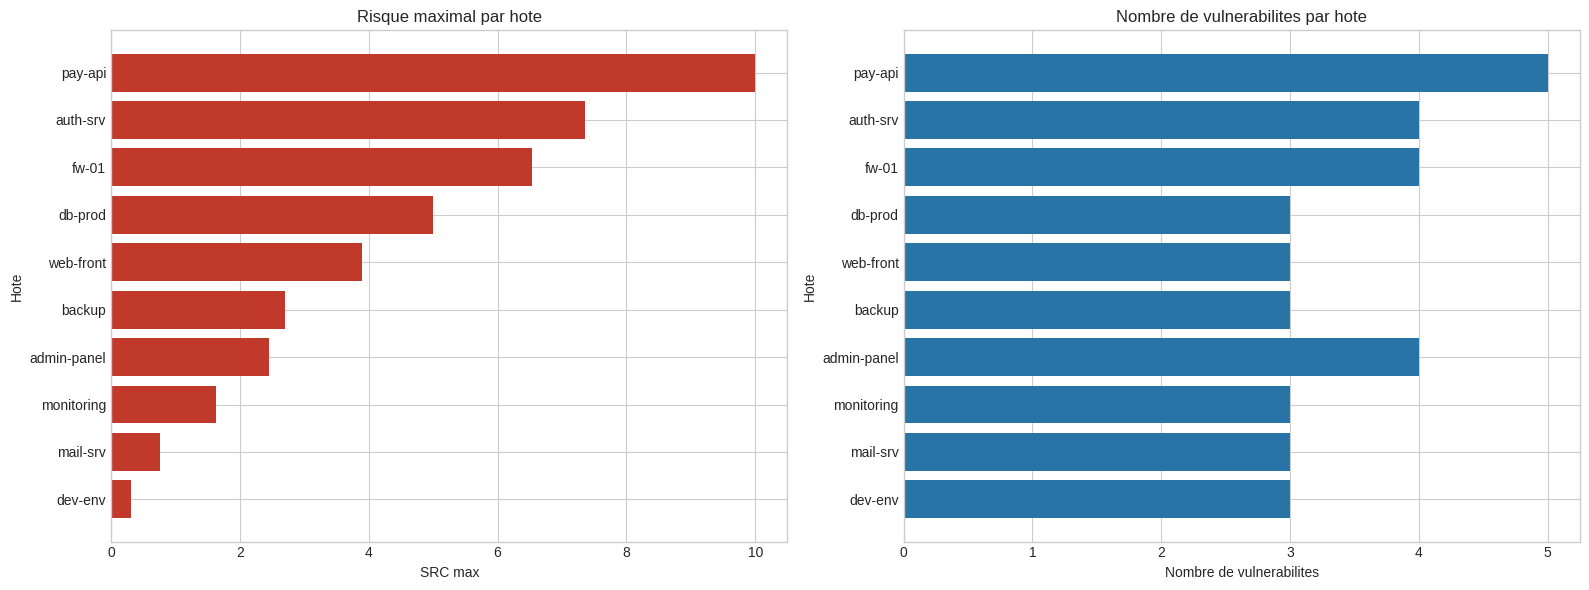

In [7]:
display(resume[["ip", "nom", "role", "src_max", "nb_vulns"]])

plot_resume = resume.sort_values("src_max")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(plot_resume["nom"], plot_resume["src_max"], color="#c0392b")
axes[0].set_title("Risque maximal par hote")
axes[0].set_xlabel("SRC max")
axes[0].set_ylabel("Hote")
axes[0].set_xlim(0, 10.5)

axes[1].barh(plot_resume["nom"], plot_resume["nb_vulns"], color="#2874a6")
axes[1].set_title("Nombre de vulnerabilites par hote")
axes[1].set_xlabel("Nombre de vulnerabilites")
axes[1].set_ylabel("Hote")

plt.tight_layout()
plt.show()

## Graphe 3 - Comparaison CVSS vs SRC V1

Ce graphique permet de montrer pourquoi le SRC est utile. Si une vulnerabilite est en dessous de la diagonale, cela veut dire que le contexte PayShield la fait baisser en priorite par rapport a sa gravite technique brute.

,id,service,cvss,src_norm,ecart_src_cvss,exposition,criticite,donnees
34,V35,Confluence,10.0,1.67,-8.33,Interne,Moyenne,Interne
24,V25,Grafana,9.8,1.63,-8.17,Interne,Moyenne,Interne
16,V17,OpenSSH,9.8,2.45,-7.35,Interne,Élevée,Interne
13,V14,Apache,9.8,2.45,-7.35,Interne,Élevée,Interne
30,V31,Apache,7.5,0.31,-7.19,Interne,Faible,Public
25,V26,Grafana,8.1,1.35,-6.75,Interne,Moyenne,Interne
15,V16,MySQL,8.8,2.20,-6.60,Interne,Élevée,Interne
31,V32,MySQL,6.5,0.27,-6.23,Interne,Faible,Public
14,V15,Apache,7.5,1.88,-5.62,Interne,Élevée,Interne
26,V27,Grafana,6.5,1.08,-5.42,Interne,Moyenne,Interne


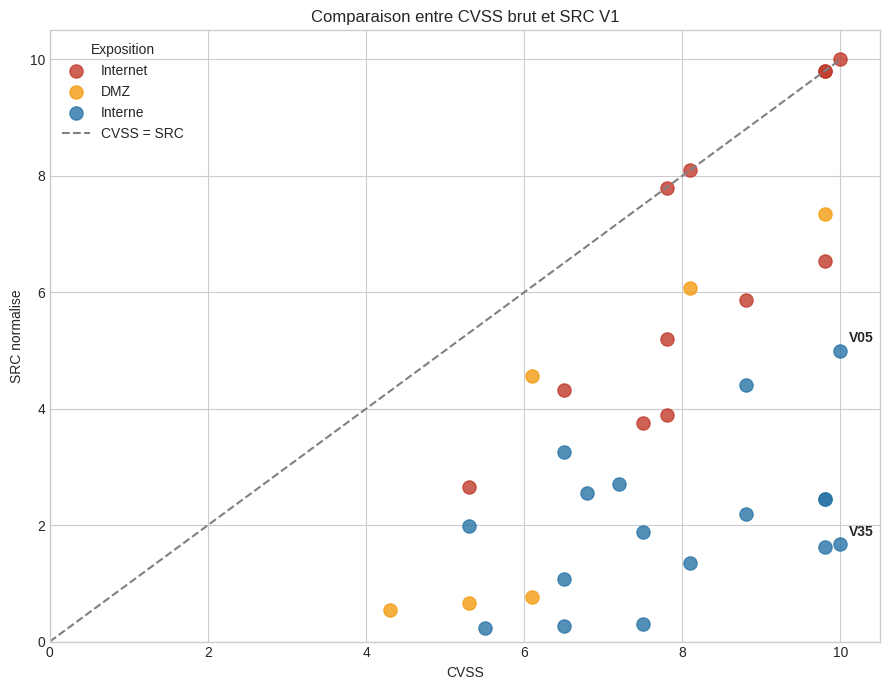

In [8]:
display(comparaison.sort_values("ecart_src_cvss")[ ["id", "service", "cvss", "src_norm", "ecart_src_cvss", "exposition", "criticite", "donnees"] ].head(10))

color_map = {"Internet": "#c0392b", "DMZ": "#f39c12", "Interne": "#2874a6"}

fig, ax = plt.subplots(figsize=(9, 7))

for exposition, color in color_map.items():
    subset = comparaison[comparaison["exposition"] == exposition]
    ax.scatter(subset["cvss"], subset["src_norm"], s=90, alpha=0.8, label=exposition, color=color)

ax.plot([0, 10], [0, 10], linestyle="--", color="gray", linewidth=1.5, label="CVSS = SRC")

for vuln_id in ["V05", "V35"]:
    point = comparaison[comparaison["id"] == vuln_id].iloc[0]
    ax.annotate(vuln_id, (point["cvss"], point["src_norm"]), xytext=(6, 6), textcoords="offset points", fontsize=10, fontweight="bold")

ax.set_title("Comparaison entre CVSS brut et SRC V1")
ax.set_xlabel("CVSS")
ax.set_ylabel("SRC normalise")
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 10.5)
ax.legend(title="Exposition")

plt.tight_layout()
plt.show()

## Expérience A — Comparer deux configurations de pondération

On teste deux jeux de coefficients pour observer l'impact sur le classement Top 10.

- **Config Base** : poids équilibrés (ceux utilisés jusqu'ici)
- **Config Alt** : exposition Internet fortement amplifiée (3.0), données Sensible renforcées (2.0), Interne pénalisé (0.5)

**Cas clé à observer** : V05 (PostgreSQL sans MDP, CVSS 10, Interne, Critique, Sensible) vs V35 (Confluence RCE, CVSS 10, Interne, Moyenne, Interne)  
→ Même CVSS, même exposition — mais contexte très différent. L'algorithme fait-il la différence ?

In [ ]:
# === EXPÉRIENCE A — Deux configs de pondération ===

configs = {
    "Config Base": {
        "Internet": 2.0, "DMZ": 1.5, "Interne": 1.0,
        "Critique": 2.0, "Élevée": 1.5, "Moyenne": 1.0, "Faible": 0.5,
        "Sensible": 1.5, "Interne_d": 1.0, "Public": 0.5,
    },
    "Config Alt": {
        "Internet": 3.0, "DMZ": 1.5, "Interne": 0.5,
        "Critique": 1.5, "Élevée": 1.2, "Moyenne": 1.0, "Faible": 0.3,
        "Sensible": 2.0, "Interne_d": 1.0, "Public": 0.2,
    },
}

def compute_top10(df, cfg):
    w_exp  = {"Internet": cfg["Internet"], "DMZ": cfg["DMZ"], "Interne": cfg["Interne"]}
    w_crit = {"Critique": cfg["Critique"], "Élevée": cfg["Élevée"], "Moyenne": cfg["Moyenne"], "Faible": cfg["Faible"]}
    w_don  = {"Sensible": cfg["Sensible"], "Interne": cfg["Interne_d"], "Public": cfg["Public"]}
    tmp = df.copy()
    tmp["we"] = tmp["exposition"].map(w_exp)
    tmp["wc"] = tmp["criticite"].map(w_crit)
    tmp["wd"] = tmp["donnees"].map(w_don)
    tmp["src"] = tmp["cvss"] * tmp["we"] * tmp["wc"] * tmp["wd"]
    src_max = tmp["src"].max()
    tmp["src_norm"] = (tmp["src"] / src_max * 10).round(2)
    return (
        tmp[["id", "ip", "service", "cvss", "exposition", "criticite", "donnees", "src_norm"]]
        .sort_values("src_norm", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

results = {name: compute_top10(vulns, cfg) for name, cfg in configs.items()}

# Affichage des tableaux
for name, df in results.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    display(df[["id", "service", "cvss", "exposition", "criticite", "donnees", "src_norm"]])

# Graphe comparatif côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, (name, df) in zip(axes, results.items()):
    plot_df = df.sort_values("src_norm")
    colors = [plt.cm.OrRd(0.35 + 0.05 * i) for i in range(len(plot_df))]
    bars = ax.barh(plot_df["id"], plot_df["src_norm"], color=colors)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("SRC normalisé")
    ax.set_xlim(0, 10.5)
    for bar, service, score in zip(bars, plot_df["service"], plot_df["src_norm"]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{service} ({score})", va="center", fontsize=8)

fig.suptitle("Expérience A — Impact du changement de coefficients sur le Top 10", fontsize=14)
plt.tight_layout()
plt.show()

# Analyse du cas limite V05 vs V35
print("\n--- Cas limite : V05 vs V35 ---")
for name, df_top in results.items():
    cas = vulns[vulns["id"].isin(["V05", "V35"])].copy()
    cfg = configs[name]
    w_exp  = {"Internet": cfg["Internet"], "DMZ": cfg["DMZ"], "Interne": cfg["Interne"]}
    w_crit = {"Critique": cfg["Critique"], "Élevée": cfg["Élevée"], "Moyenne": cfg["Moyenne"], "Faible": cfg["Faible"]}
    w_don  = {"Sensible": cfg["Sensible"], "Interne": cfg["Interne_d"], "Public": cfg["Public"]}
    cas["src"] = cas["cvss"] * cas["exposition"].map(w_exp) * cas["criticite"].map(w_crit) * cas["donnees"].map(w_don)
    cas["src_norm"] = (cas["src"] / cas["src"].max() * 10).round(2)
    print(f"\n{name}:")
    display(cas[["id", "service", "cvss", "exposition", "criticite", "donnees", "src_norm"]])

In [ ]:
# === EXPÉRIENCE A — Impact sur l'ensemble des 35 vulnérabilités ===

def compute_all(df, cfg):
    w_exp  = {"Internet": cfg["Internet"], "DMZ": cfg["DMZ"], "Interne": cfg["Interne"]}
    w_crit = {"Critique": cfg["Critique"], "Élevée": cfg["Élevée"], "Moyenne": cfg["Moyenne"], "Faible": cfg["Faible"]}
    w_don  = {"Sensible": cfg["Sensible"], "Interne": cfg["Interne_d"], "Public": cfg["Public"]}
    tmp = df.copy()
    tmp["src"] = tmp["cvss"] * tmp["exposition"].map(w_exp) * tmp["criticite"].map(w_crit) * tmp["donnees"].map(w_don)
    src_max = tmp["src"].max()
    tmp["src_norm"] = (tmp["src"] / src_max * 10).round(2)
    return tmp[["id", "service", "src_norm"]].sort_values("src_norm", ascending=False).reset_index(drop=True)

all_results = {name: compute_all(vulns, cfg) for name, cfg in configs.items()}

fig, axes = plt.subplots(1, 2, figsize=(18, 12), sharey=False)

for ax, (name, df) in zip(axes, all_results.items()):
    plot_df = df.sort_values("src_norm")
    colors = [plt.cm.OrRd(0.2 + 0.8 * (i / len(plot_df))) for i in range(len(plot_df))]
    bars = ax.barh(plot_df["id"], plot_df["src_norm"], color=colors)
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("SRC normalisé")
    ax.set_xlim(0, 10.5)
    for bar, service, score in zip(bars, plot_df["service"], plot_df["src_norm"]):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{service} ({score})", va="center", fontsize=7.5)

fig.suptitle("Expérience A — Impact du changement de coefficients sur les 35 vulnérabilités", fontsize=14)
plt.tight_layout()
plt.show()

## Expérience B — Identifier une anomalie de classement

On cherche des cas où l'algorithme SRC V1 produit un résultat **incohérent pour le RSSI de PayShield**.

### Deux anomalies identifiées

**Anomalie 1 — V05 absent du Top 10**
- PostgreSQL sans mot de passe, CVSS 10.0, BDD de paiement (Critique, Sensible)
- Classé **11e** à cause du malus "Interne" (w_exposition = 1.0)
- Pour une fintech traitant 15 000 transactions/jour, l'accès root à la BDD de paiement est une priorité absolue

**Anomalie 2 — V35 classé 26e malgré EPSS 0.94 et KEV=1**
- Confluence RCE, CVSS 10.0, EPSS 0.94 = 94% de probabilité d'exploitation dans 30 jours
- KEV=1 → exploit actif recensé par la CISA
- L'algorithme SRC V1 **ignore totalement l'EPSS et le KEV**
- V35 est pénalisé (Moyenne, Interne) mais reste une menace imminente

### Conclusion
Le SRC V1 ne capture pas la **probabilité d'exploitation réelle**. Deux vulnérabilités avec CVSS 10 peuvent avoir des niveaux de menace immédiate très différents selon leur EPSS et leur présence dans le KEV catalog.

In [ ]:
# === EXPÉRIENCE B — Anomalies de classement ===

# Classement complet SRC V1
ranked = (
    vulns[["id", "ip", "service", "cvss", "epss", "kev", "exposition", "criticite", "donnees", "src_norm"]]
    .sort_values("src_norm", ascending=False)
    .reset_index(drop=True)
)
ranked.index += 1
ranked["rang"] = ranked.index

# --- Anomalie 1 : V05 hors Top 10 ---
print("=" * 70)
print("ANOMALIE 1 — V05 (PostgreSQL BDD paiement) classé hors du Top 10")
print("=" * 70)
v05 = ranked[ranked["id"] == "V05"]
print(f"Rang de V05 : {v05['rang'].values[0]}e sur {len(ranked)}")
print()
display(v05[["id", "service", "cvss", "epss", "kev", "exposition", "criticite", "donnees", "src_norm"]])

print("\n→ Le malus exposition 'Interne' (×1.0) fait chuter la BDD de paiement hors du Top 10.")
print("  Pour un RSSI fintech, c'est une anomalie critique : accès root à 15 000 tx/jour.\n")

# --- Anomalie 2 : V35 EPSS 0.94 ignoré ---
print("=" * 70)
print("ANOMALIE 2 — V35 (Confluence RCE) classé 26e malgré EPSS 0.94 + KEV=1")
print("=" * 70)
v35 = ranked[ranked["id"] == "V35"]
print(f"Rang de V35 : {v35['rang'].values[0]}e sur {len(ranked)}")
print()
display(v35[["id", "service", "cvss", "epss", "kev", "exposition", "criticite", "donnees", "src_norm"]])

print("\n→ EPSS 0.94 = 94% de probabilité d'exploitation dans 30 jours.")
print("  KEV=1 = exploit actif recensé par la CISA.")
print("  Le SRC V1 ignore ces deux signaux — V35 est une menace imminente mal classée.\n")

# --- Graphe : Top 15 avec V05 et V35 mis en évidence ---
top15 = ranked.head(15).copy()

# Ajouter V35 si absent
if "V35" not in top15["id"].values:
    v35_row = ranked[ranked["id"] == "V35"].copy()
    top15 = pd.concat([top15, v35_row]).reset_index(drop=True)

plot_df = top15.sort_values("src_norm")

colors = []
for vid in plot_df["id"]:
    if vid == "V05":
        colors.append("#e74c3c")   # rouge vif — anomalie critique
    elif vid == "V35":
        colors.append("#f39c12")   # orange — anomalie EPSS
    else:
        colors.append("#95a5a6")   # gris neutre

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(plot_df["id"], plot_df["src_norm"], color=colors)

ax.set_title("Expérience B — Anomalies de classement (V05 et V35 mis en évidence)", fontsize=13)
ax.set_xlabel("SRC normalisé (V1)")
ax.set_xlim(0, 11.5)

for bar, row in zip(bars, plot_df.itertuples()):
    label = f"{row.service} | EPSS {row.epss} | KEV {row.kev} | {row.criticite}"
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            label, va="center", fontsize=8)

# Annotations
for vid, color, note in [("V05", "#e74c3c", "BDD paiement — hors Top 10 !"),
                          ("V35", "#f39c12", "EPSS 0.94 + KEV — ignoré !")]:
    row = plot_df[plot_df["id"] == vid].iloc[0]
    bar_idx = plot_df[plot_df["id"] == vid].index[0]
    ax.annotate(note,
                xy=(row["src_norm"], list(plot_df["id"]).index(vid)),
                xytext=(row["src_norm"] + 0.5, list(plot_df["id"]).index(vid) + 0.4),
                fontsize=9, color=color, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e74c3c", label="V05 — Anomalie criticité métier"),
    Patch(facecolor="#f39c12", label="V35 — Anomalie EPSS/KEV ignoré"),
    Patch(facecolor="#95a5a6", label="Autres vulnérabilités"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

## Synthèse — Analyse de l'algorithme SRC

### Problématique en 3 phrases

**Le problème :** PayShield reçoit des dizaines de vulnérabilités avec un score CVSS identique, sans moyen de prioriser la remédiation selon son contexte métier fintech.

**Pourquoi il existe :** Le CVSS est un score de gravité technique universel — il ne connaît ni l'exposition réseau, ni la criticité du système, ni la sensibilité des données traitées ; deux vulnérabilités CVSS 10 sur la BDD de paiement et sur un serveur de dev reçoivent la même priorité.

**Comment on y répond :** Le SRC (Score de Risque Contextuel) pondère le CVSS par trois facteurs métier (exposition × criticité × données) pour produire un classement adapté à la réalité de PayShield — mais l'Expérience A montre que le choix des coefficients reste subjectif, et l'Expérience B révèle que la probabilité d'exploitation réelle (EPSS, KEV) est encore ignorée.

In [ ]:
# === SYNTHÈSE A — Tableau comparatif des deux configs ===

top_base = results["Config Base"].copy()
top_alt  = results["Config Alt"].copy()

top_base["rang_base"] = range(1, len(top_base) + 1)
top_alt["rang_alt"]   = range(1, len(top_alt) + 1)

# Fusion sur les IDs présents dans au moins un des deux Top 10
all_ids = pd.Index(list(dict.fromkeys(list(top_base["id"]) + list(top_alt["id"]))))
comparatif = pd.DataFrame({"id": all_ids})
comparatif = comparatif.merge(top_base[["id", "service", "src_norm", "rang_base"]].rename(columns={"src_norm": "src_base"}), on="id", how="left")
comparatif = comparatif.merge(top_alt[["id", "src_norm", "rang_alt"]].rename(columns={"src_norm": "src_alt"}), on="id", how="left")

comparatif["rang_base"] = comparatif["rang_base"].fillna("—")
comparatif["rang_alt"]  = comparatif["rang_alt"].fillna("—")

def delta_rang(row):
    try:
        return int(row["rang_base"]) - int(row["rang_alt"])
    except:
        return None

comparatif["delta"] = comparatif.apply(delta_rang, axis=1)

def interprete(row):
    if row["rang_base"] == "—":
        return "▲ Entre dans le Top 10"
    if row["rang_alt"] == "—":
        return "▼ Sort du Top 10"
    d = row["delta"]
    if d > 0:
        return f"↑ Gagne {d} place(s)"
    elif d < 0:
        return f"↓ Perd {abs(d)} place(s)"
    return "= Stable"

comparatif["mouvement"] = comparatif.apply(interprete, axis=1)

nb_changements = comparatif[comparatif["delta"].notna() & (comparatif["delta"] != 0)].shape[0]
nb_entrees = comparatif[comparatif["rang_base"] == "—"].shape[0]
nb_sorties = comparatif[comparatif["rang_alt"] == "—"].shape[0]

print("=" * 70)
print("TABLEAU COMPARATIF — Expérience A (Config Base vs Config Alt)")
print("=" * 70)
display(comparatif[["id", "service", "rang_base", "src_base", "rang_alt", "src_alt", "mouvement"]])

print(f"\n→ {nb_changements} vulnérabilité(s) changent de position")
print(f"→ {nb_entrees} entrée(s) dans le Top 10 (Config Alt uniquement)")
print(f"→ {nb_sorties} sortie(s) du Top 10 (Config Base uniquement)")
print("\nExplication : Config Alt surpondère l'exposition Internet (×3.0) et les données Sensibles (×2.0),")
print("ce qui propulse les vulnérabilités Internet/Sensible et écrase les vulnérabilités Interne.")

# === SYNTHÈSE B — Anomalie retenue + piste de correction ===
print("\n" + "=" * 70)
print("ANOMALIE RETENUE — V05 (PostgreSQL BDD paiement) absent du Top 10")
print("=" * 70)
display(vulns[vulns["id"] == "V05"][["id", "service", "cvss", "epss", "kev", "exposition", "criticite", "donnees", "src_norm"]])

print("""
Explication :
  V05 a un CVSS 10.0 sur la base de données de paiement (Critique, Sensible),
  mais son exposition "Interne" lui applique un coefficient ×1.0, contre ×2.0
  pour les systèmes Internet. Résultat : il est classé 11e, hors du Top 10.

Problème pour PayShield :
  Un accès root sans mot de passe sur la BDD traitant 15 000 transactions/jour
  représente un risque métier maximal — indépendamment de l'exposition réseau.
  Un attaquant ayant compromis un poste interne accède directement à la BDD.

Piste de correction (SRC V2) :
  Intégrer l'EPSS pour pondérer la probabilité d'exploitation réelle :

    SRC_v2 = SRC × (1 + epss)

  → V05 (EPSS 0.45) : SRC multiplié par 1.45
  → V35 (EPSS 0.94) : SRC multiplié par 1.94 — remonte significativement

  Ou intégrer la pénalité KEV (exploit actif) :

    SRC_v2 = SRC × (1 + 1.5 × kev)

  → V35 (KEV=1) : SRC multiplié par 2.5 — signal d'urgence immédiat
""")

## Amélioration — SRC V2 avec EPSS (Option A)

### Limites identifiées du SRC V1

1. **Coefficients fixes et arbitraires** — deux RSSI produiront des classements différents (démontré en Expérience A)
2. **Aucune prise en compte de la probabilité d'exploitation** — une faille CVSS 10 avec EPSS 0.02 est traitée comme une faille CVSS 10 avec EPSS 0.97
3. **Pas de distinction faille théorique / faille activement exploitée** — la colonne KEV (CISA Known Exploited Vulnerabilities) est ignorée

### Nouvelle formule

```
SRC_v2 = SRC_v1 × (1 + epss)
```

L'EPSS (Exploit Prediction Scoring System) donne la probabilité d'exploitation dans les 30 prochains jours.  
Le facteur `(1 + epss)` amplifie les failles réellement dangereuses sans écraser les autres.

In [ ]:
# === SRC V2 — Intégration de l'EPSS ===

# SRC V1 déjà calculé dans vulns["src_norm"]
# SRC V2 = SRC_v1 × (1 + epss), puis renormalisation
vulns["src_v2_raw"] = vulns["src"] * (1 + vulns["epss"])
vulns["src_v2"]     = (vulns["src_v2_raw"] / vulns["src_v2_raw"].max() * 10).round(2)

# Top 10 V1 et V2
top10_v1 = (
    vulns.sort_values("src_norm", ascending=False)
    .head(10)
    .reset_index(drop=True)
    [["id", "service", "cvss", "epss", "exposition", "criticite", "donnees", "src_norm"]]
)
top10_v1.index += 1

top10_v2 = (
    vulns.sort_values("src_v2", ascending=False)
    .head(10)
    .reset_index(drop=True)
    [["id", "service", "cvss", "epss", "exposition", "criticite", "donnees", "src_v2"]]
)
top10_v2.index += 1

print("=" * 70)
print("TOP 10 — SRC V1 (sans EPSS)")
print("=" * 70)
display(top10_v1)

print("=" * 70)
print("TOP 10 — SRC V2 (avec EPSS)")
print("=" * 70)
display(top10_v2)

# Comparaison des rangs
rang_v1 = {row["id"]: i+1 for i, row in vulns.sort_values("src_norm", ascending=False).reset_index(drop=True).iterrows()}
rang_v2 = {row["id"]: i+1 for i, row in vulns.sort_values("src_v2",   ascending=False).reset_index(drop=True).iterrows()}

ids_union = list(dict.fromkeys(list(top10_v1["id"]) + list(top10_v2["id"])))
comparaison_v2 = pd.DataFrame({
    "id": ids_union,
    "rang_v1": [rang_v1[v] for v in ids_union],
    "rang_v2": [rang_v2[v] for v in ids_union],
})
comparaison_v2["mouvement"] = comparaison_v2.apply(
    lambda r: f"↑ +{r['rang_v1']-r['rang_v2']}" if r['rang_v1'] > r['rang_v2']
              else (f"↓ {r['rang_v1']-r['rang_v2']}" if r['rang_v1'] < r['rang_v2'] else "= stable"),
    axis=1
)
comparaison_v2 = comparaison_v2.merge(vulns[["id","service","epss","kev"]], on="id")

print("=" * 70)
print("COMPARAISON DES RANGS V1 → V2")
print("=" * 70)
display(comparaison_v2[["id", "service", "epss", "kev", "rang_v1", "rang_v2", "mouvement"]])

nb_changements = (comparaison_v2["rang_v1"] != comparaison_v2["rang_v2"]).sum()
entrees = [v for v in top10_v2["id"] if v not in list(top10_v1["id"])]
sorties = [v for v in top10_v1["id"] if v not in list(top10_v2["id"])]
print(f"\n→ {nb_changements} changement(s) de position dans le Top 10")
print(f"→ Entrent dans le Top 10 : {entrees if entrees else 'aucun'}")
print(f"→ Sortent du Top 10      : {sorties if sorties else 'aucun'}")

# Graphe avant / après côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, (title, df, col) in zip(axes, [
    ("SRC V1 — sans EPSS", top10_v1.sort_values("src_norm"), "src_norm"),
    ("SRC V2 — avec EPSS", top10_v2.sort_values("src_v2"),   "src_v2"),
]):
    colors = [plt.cm.OrRd(0.35 + 0.05 * i) for i in range(len(df))]
    bars = ax.barh(df["id"], df[col], color=colors)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("SRC normalisé")
    ax.set_xlim(0, 10.5)
    for bar, row in zip(bars, df.itertuples()):
        score = getattr(row, col)
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{row.service} | EPSS {row.epss} ({score})", va="center", fontsize=8)

fig.suptitle("SRC V1 vs SRC V2 — Impact de l'intégration de l'EPSS sur le Top 10", fontsize=14)
plt.tight_layout()
plt.show()

## Rapport HTML — Génération automatique

Génération d'un fichier `rapport.html` complet avec :
- En-tête : cible, date, résumé exécutif
- Tableau Top 10 (SRC V2)
- Sections Impact + Recommandation pour le Top 3
- Plan de remédiation J+7 / J+30 / J+90

In [ ]:
from datetime import date

# === DONNÉES DU RAPPORT ===
cible = "PayShield Fintech"
date_rapport = date.today().strftime("%d/%m/%Y")

top10_rapport = (
    vulns.sort_values("src_v2", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_rapport.index += 1
top10_rapport["rang"] = top10_rapport.index

top3 = top10_rapport.head(3)

# Impact et recommandation par service
FICHES = {
    "OpenSSL": {
        "impact": "Fuite mémoire SSL (Heartbleed) exposant les clés privées, tokens de session et données bancaires en transit. Compromission silencieuse possible sans laisser de trace dans les logs.",
        "recommandation": "Mettre à jour OpenSSL vers la version 3.x immédiatement. Révoquer et renouveler tous les certificats TLS. Auditer les logs de connexion des 30 derniers jours.",
    },
    "Apache": {
        "impact": "Path traversal et RCE sans authentification (CVE-2021-41773). Un attaquant peut exécuter des commandes arbitraires sur le serveur web et pivoter vers le réseau interne.",
        "recommandation": "Appliquer le patch Apache 2.4.50+. Désactiver mod_cgi si non utilisé. Mettre en place un WAF devant le service HTTP.",
    },
    "Kubernetes API": {
        "impact": "Accès non authentifié à l'API Kubernetes permettant le déploiement de conteneurs malveillants et la prise de contrôle complète du cluster de paiement.",
        "recommandation": "Activer l'authentification RBAC sur l'API server. Restreindre l'accès à l'API aux seules IP d'administration. Auditer les workloads déployés.",
    },
    "Node.js": {
        "impact": "Corruption mémoire dans le runtime Node.js pouvant mener à un RCE sur le service d'API de paiement exposé sur Internet.",
        "recommandation": "Mettre à jour Node.js vers la version LTS courante (20.x). Isoler le processus Node.js dans un conteneur avec droits minimaux.",
    },
    "PostgreSQL": {
        "impact": "Accès root à la base de données de paiement sans authentification. Extraction, modification ou suppression de l'ensemble des transactions et données KYC de 1,2 M d'utilisateurs.",
        "recommandation": "Définir un mot de passe fort sur le compte postgres immédiatement. Activer pg_hba.conf pour restreindre les connexions aux seuls hosts applicatifs. Activer l'audit pgaudit.",
    },
    "Keycloak": {
        "impact": "Contournement d'authentification sur le serveur IAM central. Permet la création de comptes admin et la prise de contrôle de toutes les identités PayShield.",
        "recommandation": "Mettre à jour Keycloak vers la version 22+. Activer le MFA sur tous les comptes admin. Vérifier les realm policies et les sessions actives.",
    },
    "pfSense": {
        "impact": "Compromission du pare-feu périmétrique exposant l'ensemble du réseau interne PayShield à une attaque directe depuis Internet.",
        "recommandation": "Mettre à jour pfSense vers la dernière version stable. Désactiver l'accès à l'interface d'administration depuis les interfaces WAN.",
    },
    "OpenSSH": {
        "impact": "Énumération des utilisateurs valides du système permettant des attaques ciblées par force brute ou credential stuffing.",
        "recommandation": "Mettre à jour OpenSSH vers 8.x+. Désactiver l'authentification par mot de passe, imposer les clés SSH. Activer fail2ban.",
    },
    "Confluence": {
        "impact": "RCE via injection OGNL (EPSS 0.94, KEV=1). Exploit public disponible — exploitation active recensée par la CISA dans les 30 prochains jours.",
        "recommandation": "Appliquer le patch Confluence immédiatement ou isoler le service du réseau. Vérifier les logs d'accès pour détection d'exploitation.",
    },
    "Nginx": {
        "impact": "Vulnérabilité sur le serveur web frontal pouvant permettre une divulgation d'informations ou un déni de service affectant la disponibilité du portail PayShield.",
        "recommandation": "Mettre à jour Nginx vers la version stable courante. Vérifier la configuration des headers de sécurité (CSP, HSTS).",
    },
}

def get_fiche(service):
    for key in FICHES:
        if key.lower() in service.lower():
            return FICHES[key]
    return {
        "impact": f"Vulnérabilité sur {service} pouvant compromettre la disponibilité ou l'intégrité du système concerné.",
        "recommandation": f"Appliquer les correctifs disponibles pour {service} et surveiller les accès au service.",
    }

def criticite_badge(c):
    colors = {"Critique": "#c0392b", "Élevée": "#e67e22", "Moyenne": "#f1c40f", "Faible": "#27ae60"}
    color = colors.get(c, "#7f8c8d")
    return f'<span style="background:{color};color:white;padding:2px 8px;border-radius:4px;font-size:0.85em">{c}</span>'

def score_color(score):
    if score >= 8:   return "#c0392b"
    if score >= 6:   return "#e67e22"
    if score >= 4:   return "#f39c12"
    return "#27ae60"

# === GÉNÉRATION HTML ===
rows_top10 = ""
for _, row in top10_rapport.iterrows():
    cve_str = row["cve"] if str(row["cve"]) != "nan" and row["cve"] != "-" else "—"
    kev_badge = ' <span style="background:#8e44ad;color:white;padding:1px 6px;border-radius:3px;font-size:0.75em">KEV</span>' if row.get("kev", 0) == 1 else ""
    rows_top10 += f"""
    <tr>
        <td style="text-align:center;font-weight:bold">{int(row['rang'])}</td>
        <td>{row['ip']}</td>
        <td>{row['service']}</td>
        <td style="font-size:0.85em">{cve_str}{kev_badge}</td>
        <td style="text-align:center;color:{score_color(row['src_v2'])};font-weight:bold">{row['src_v2']}</td>
        <td style="text-align:center">{criticite_badge(row['criticite'])}</td>
        <td style="text-align:center">{row['epss']}</td>
    </tr>"""

sections_top3 = ""
for _, row in top3.iterrows():
    fiche = get_fiche(row["service"])
    sections_top3 += f"""
    <div style="border:1px solid #ddd;border-radius:8px;padding:20px;margin-bottom:20px;border-left:5px solid {score_color(row['src_v2'])}">
        <h3 style="margin:0 0 8px 0">#{int(row['rang'])} — {row['service']} ({row['ip']})</h3>
        <p style="margin:0 0 12px 0;color:#666;font-size:0.9em">CVE : {row['cve']} &nbsp;|&nbsp; CVSS : {row['cvss']} &nbsp;|&nbsp; SRC V2 : <strong>{row['src_v2']}</strong> &nbsp;|&nbsp; EPSS : {row['epss']}</p>
        <table style="width:100%;border-collapse:collapse">
            <tr>
                <td style="width:50%;vertical-align:top;padding-right:16px">
                    <h4 style="color:#c0392b;margin:0 0 6px 0">Impact</h4>
                    <p style="margin:0;font-size:0.95em">{fiche['impact']}</p>
                </td>
                <td style="width:50%;vertical-align:top;padding-left:16px;border-left:1px solid #eee">
                    <h4 style="color:#27ae60;margin:0 0 6px 0">Recommandation</h4>
                    <p style="margin:0;font-size:0.95em">{fiche['recommandation']}</p>
                </td>
            </tr>
        </table>
    </div>"""

html = f"""<!DOCTYPE html>
<html lang="fr">
<head>
<meta charset="UTF-8">
<title>Rapport de vulnérabilités — {cible}</title>
<style>
  body {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 0 auto; padding: 32px; color: #2c3e50; }}
  h1 {{ color: #2c3e50; margin-bottom: 4px; }}
  h2 {{ color: #2c3e50; border-bottom: 2px solid #e74c3c; padding-bottom: 6px; margin-top: 40px; }}
  table {{ width: 100%; border-collapse: collapse; margin-top: 12px; }}
  th {{ background: #2c3e50; color: white; padding: 10px 12px; text-align: left; }}
  td {{ padding: 9px 12px; border-bottom: 1px solid #eee; }}
  tr:nth-child(even) {{ background: #f9f9f9; }}
  .header-box {{ background: #f4f6f8; border-radius: 8px; padding: 20px 28px; margin-bottom: 32px; }}
  .resume {{ background: #eaf4fb; border-left: 4px solid #2980b9; padding: 14px 18px; border-radius: 4px; margin-top: 12px; }}
  .footer {{ background: #2c3e50; color: white; border-radius: 8px; padding: 20px 28px; margin-top: 48px; }}
  .footer h2 {{ color: white; border-bottom: 1px solid #7f8c8d; }}
  .plan-grid {{ display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px; margin-top: 12px; }}
  .plan-card {{ background: #34495e; border-radius: 6px; padding: 14px; }}
  .plan-card h4 {{ margin: 0 0 8px 0; color: #e74c3c; }}
  .plan-card ul {{ margin: 0; padding-left: 18px; font-size: 0.9em; }}
</style>
</head>
<body>

<div class="header-box">
  <h1>Rapport de Gestion des Vulnérabilités</h1>
  <p style="margin:4px 0;color:#666">Cible : <strong>{cible}</strong> &nbsp;|&nbsp; Date : <strong>{date_rapport}</strong> &nbsp;|&nbsp; Périmètre : 10 systèmes, 35 vulnérabilités</p>
  <div class="resume">
    <strong>Résumé exécutif</strong><br><br>
    L'analyse de sécurité conduite sur l'infrastructure de PayShield a identifié <strong>35 vulnérabilités sur 10 systèmes</strong>,
    dont plusieurs de criticité maximale (CVSS 10.0) exposées directement sur Internet et traitant des données de paiement sensibles.
    Le Score de Risque Contextuel V2 (SRC V2), enrichi par l'EPSS, révèle que les systèmes <strong>pay-api</strong> et <strong>db-prod</strong>
    concentrent les risques les plus élevés et doivent faire l'objet d'une remédiation immédiate sous <strong>7 jours</strong>.
    Sans action corrective, PayShield s'expose à une compromission de sa base de paiement, une violation PCI-DSS et un impact direct
    sur ses 1,2 million d'utilisateurs.
  </div>
</div>

<h2>Top 10 des vulnérabilités — Score de Risque Contextuel V2</h2>
<table>
  <thead>
    <tr>
      <th>#</th><th>IP</th><th>Service</th><th>CVE</th><th>SRC V2</th><th>Criticité</th><th>EPSS</th>
    </tr>
  </thead>
  <tbody>{rows_top10}</tbody>
</table>

<h2>Analyse détaillée — Top 3</h2>
{sections_top3}

<div class="footer">
  <h2>Plan de remédiation</h2>
  <div class="plan-grid">
    <div class="plan-card">
      <h4>J+7 — Actions immédiates</h4>
      <ul>
        <li>Patcher OpenSSL (Heartbleed) sur pay-api</li>
        <li>Mettre à jour Apache 2.4.50+ sur web-front</li>
        <li>Définir un mot de passe PostgreSQL sur db-prod</li>
        <li>Isoler l'API Kubernetes du réseau public</li>
      </ul>
    </div>
    <div class="plan-card">
      <h4>J+30 — Remédiation planifiée</h4>
      <ul>
        <li>Mettre à jour Keycloak sur auth-srv</li>
        <li>Patcher pfSense sur fw-01</li>
        <li>Déployer fail2ban sur tous les serveurs SSH</li>
        <li>Activer pgaudit sur db-prod</li>
      </ul>
    </div>
    <div class="plan-card">
      <h4>J+90 — Hardening structurel</h4>
      <ul>
        <li>Révision complète de la politique IAM</li>
        <li>Segmentation réseau DMZ / Interne renforcée</li>
        <li>Déploiement d'un WAF périmétrique</li>
        <li>Intégration EPSS dans le cycle de patch management</li>
      </ul>
    </div>
  </div>
  <p style="margin-top:16px;font-size:0.85em;color:#95a5a6">
    Rapport généré automatiquement par l'outil de scoring SRC V2 — PayShield Fintech — {date_rapport}
  </p>
</div>

</body>
</html>"""

with open("rapport.html", "w", encoding="utf-8") as f:
    f.write(html)

print(f"Rapport généré : rapport.html ({len(html):,} caractères)")
print("Ouvrir dans un navigateur : firefox rapport.html  ou  google-chrome rapport.html")

## Extra — SRC V3 : Combinaison EPSS + KEV

### Formule combinée

```
SRC_v3 = SRC × (1 + epss) × (1 + 1.5 × kev)
```

- `(1 + epss)` : amplifie selon la probabilité d'exploitation réelle (0 → ×1.0, 0.97 → ×1.97)
- `(1 + 1.5 × kev)` : pénalité exploit actif — KEV=1 multiplie par **×2.5**, KEV=0 laisse inchangé

Comparaison des 3 versions côte à côte pour mesurer l'impact cumulé.

In [ ]:
# === SRC V3 — EPSS + KEV ===

vulns["src_v3_raw"] = vulns["src"] * (1 + vulns["epss"]) * (1 + 1.5 * vulns["kev"])
vulns["src_v3"]     = (vulns["src_v3_raw"] / vulns["src_v3_raw"].max() * 10).round(2)

# Top 10 pour chaque version
def top10_version(col, label):
    df = (
        vulns.sort_values(col, ascending=False)
        .head(10)
        .reset_index(drop=True)
        [["id", "service", "cvss", "epss", "kev", "exposition", "criticite", col]]
    )
    df.index += 1
    df["rang"] = df.index
    df["version"] = label
    df = df.rename(columns={col: "score"})
    return df

t1 = top10_version("src_norm", "V1 — Base")
t2 = top10_version("src_v2",   "V2 — EPSS")
t3 = top10_version("src_v3",   "V3 — EPSS+KEV")

# Tableau comparatif des rangs
rang_v1 = {r["id"]: i+1 for i, r in vulns.sort_values("src_norm", ascending=False).reset_index(drop=True).iterrows()}
rang_v2 = {r["id"]: i+1 for i, r in vulns.sort_values("src_v2",   ascending=False).reset_index(drop=True).iterrows()}
rang_v3 = {r["id"]: i+1 for i, r in vulns.sort_values("src_v3",   ascending=False).reset_index(drop=True).iterrows()}

all_ids = list(dict.fromkeys(list(t1["id"]) + list(t2["id"]) + list(t3["id"])))
comp = pd.DataFrame({"id": all_ids})
comp = comp.merge(vulns[["id","service","epss","kev"]], on="id")
comp["rang_v1"] = comp["id"].map(rang_v1)
comp["rang_v2"] = comp["id"].map(rang_v2)
comp["rang_v3"] = comp["id"].map(rang_v3)
comp["v1→v2"] = comp.apply(lambda r: f"↑+{r['rang_v1']-r['rang_v2']}" if r['rang_v1']>r['rang_v2'] else (f"↓{r['rang_v1']-r['rang_v2']}" if r['rang_v1']<r['rang_v2'] else "="), axis=1)
comp["v2→v3"] = comp.apply(lambda r: f"↑+{r['rang_v2']-r['rang_v3']}" if r['rang_v2']>r['rang_v3'] else (f"↓{r['rang_v2']-r['rang_v3']}" if r['rang_v2']<r['rang_v3'] else "="), axis=1)

print("=" * 80)
print("COMPARAISON DES RANGS — V1 (Base) | V2 (EPSS) | V3 (EPSS+KEV)")
print("=" * 80)
display(comp[["id","service","epss","kev","rang_v1","rang_v2","v1→v2","rang_v3","v2→v3"]])

# Cas particuliers
print("\n--- Focus V35 (Confluence, EPSS 0.94, KEV=1) ---")
v35_scores = vulns[vulns["id"]=="V35"][["id","service","cvss","epss","kev","src_norm","src_v2","src_v3"]].copy()
v35_scores["rang_v1"] = rang_v1["V35"]
v35_scores["rang_v2"] = rang_v2["V35"]
v35_scores["rang_v3"] = rang_v3["V35"]
display(v35_scores)

# === GRAPHE — 3 Top 10 côte à côte ===
fig, axes = plt.subplots(1, 3, figsize=(26, 7), sharey=False)

for ax, (df, col, title) in zip(axes, [
    (t1.sort_values("score"), "score", "SRC V1 — Base"),
    (t2.sort_values("score"), "score", "SRC V2 — EPSS"),
    (t3.sort_values("score"), "score", "SRC V3 — EPSS + KEV"),
]):
    colors = [plt.cm.OrRd(0.35 + 0.05 * i) for i in range(len(df))]
    bars = ax.barh(df["id"], df[col], color=colors)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("SRC normalisé")
    ax.set_xlim(0, 10.5)
    for bar, row in zip(bars, df.itertuples()):
        kev_tag = " [KEV]" if row.kev == 1 else ""
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
                f"{row.service}{kev_tag} ({row.score})", va="center", fontsize=8)

fig.suptitle("Comparaison SRC V1 | V2 (EPSS) | V3 (EPSS+KEV) — Top 10 PayShield", fontsize=14)
plt.tight_layout()
plt.show()